<a href="https://colab.research.google.com/github/lindlabs/telecom-x-churn/blob/main/TelecomX_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
print(" Herramientas listas.")


 Herramientas listas.


In [8]:
# 1. Definimos la URL de la API de Telecom X
url_api = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# 2. Cargamos los datos directamente desde la URL
response = requests.get(url_api)
data_json = response.json()

# 3. Convertimos los datos a un DataFrame de Pandas
df_telecom = pd.DataFrame(data_json)

# 4. Mostramos el resultado
print(" Datos de la API cargados exitosamente.")
df_telecom.head()

 Datos de la API cargados exitosamente.


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [10]:
# 1. "Aplanamos" o expandimos las columnas que tienen diccionarios
df_final = pd.concat([
    df_telecom.drop(['customer', 'phone', 'internet', 'account'], axis=1),
    pd.json_normalize(df_telecom['customer']),
    pd.json_normalize(df_telecom['phone']),
    pd.json_normalize(df_telecom['internet']),
    pd.json_normalize(df_telecom['account'])
], axis=1)

# 2. Verificamos que ahora cada dato tenga su propia columna
print(" Datos expandidos y listos para el análisis.")
df_final.head()

 Datos expandidos y listos para el análisis.


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head() # Esto nos muestra las primeras 5 filas

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
print(" Datos transformados.")

 Datos transformados.


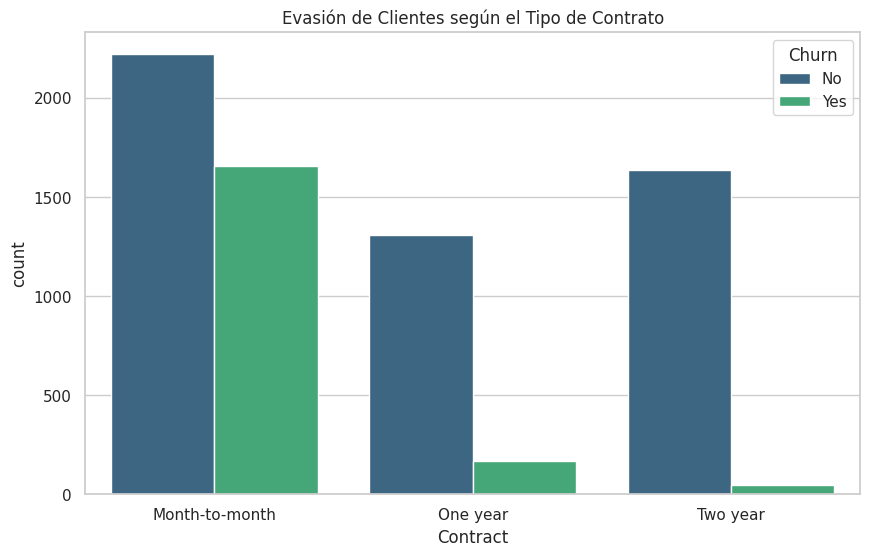

El 26.58% de los clientes se han ido.


In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Evasión de Clientes según el Tipo de Contrato')
plt.show()

tasa = df['Churn'].value_counts(normalize=True) * 100
print(f"El {tasa['Yes']:.2f}% de los clientes se han ido.")

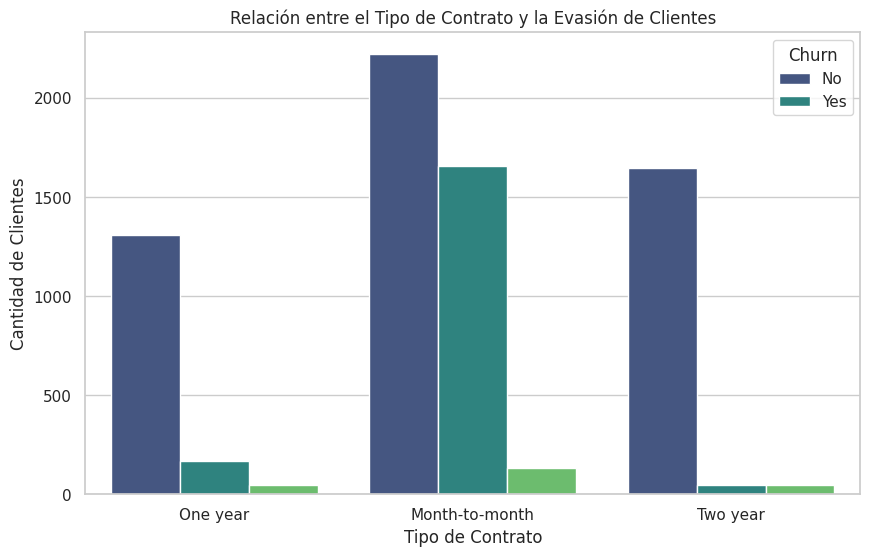


Resumen de clientes por contrato y estado de Churn:
Contract        Churn
Month-to-month  No       2220
                Yes      1655
                          130
One year        No       1307
                Yes       166
                           46
Two year        No       1647
                           48
                Yes        48
Name: count, dtype: int64


In [11]:
# 1. Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# 2. Crear un gráfico de barras comparativo (Contract vs Churn)
sns.countplot(x='Contract', hue='Churn', data=df_final, palette='viridis')

# 3. Personalizar títulos y etiquetas
plt.title('Relación entre el Tipo de Contrato y la Evasión de Clientes')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')

# 4. Mostrar el gráfico
plt.show()

# 5. Obtener los números exactos para el informe
print("\nResumen de clientes por contrato y estado de Churn:")
print(df_final.groupby('Contract')['Churn'].value_counts())


In [12]:
# Ver el resumen técnico del dataset expandido
print("--- Información General del Dataset ---")
df_final.info()

# Ver solo los tipos de datos de forma limpia
print("\n--- Tipos de Datos ---")
print(df_final.dtypes)

--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Co

In [14]:
# Convertimos los Cargos Totales a formato numerico
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

# Verificamos el cambio
print(df_final['Charges.Total'].dtype)

float64


In [15]:
# 1. Limpieza de Cargos Totales: Convertimos a número y manejamos errores
# errors='coerce' transformará los espacios vacíos en 'NaN' (nulo)
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

# 2. Eliminamos las filas que quedaron con valores nulos tras la conversión
df_final = df_final.dropna(subset=['Charges.Total'])

# 3. Selección de Variables Relevantes
# Seleccionamos las columnas que, segun el diccionario, afectan mas al Churn
columnas_clave = ['tenure', 'Contract', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total', 'Churn']
df_estudio = df_final[columnas_clave]

print(" Limpieza completada.")
print(f"Dataset final listo con {df_estudio.shape[0]} registros y las variables clave seleccionadas.")
df_estudio.head()

 Limpieza completada.
Dataset final listo con 7256 registros y las variables clave seleccionadas.


,tenure,Contract,PaymentMethod,Charges.Monthly,Charges.Total,Churn
0,9,One year,Mailed check,65.6,593.30,No
1,9,Month-to-month,Mailed check,59.9,542.40,No
2,4,Month-to-month,Electronic check,73.9,280.85,Yes
3,13,Month-to-month,Electronic check,98.0,1237.85,Yes
4,3,Month-to-month,Mailed check,83.9,267.40,Yes


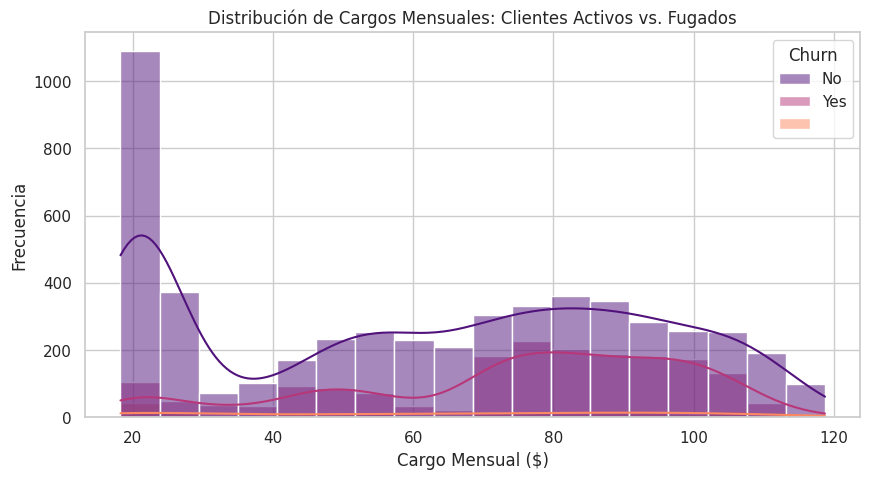

In [16]:
# Gráfico de distribución de Cargos Mensuales
plt.figure(figsize=(10, 5))
sns.histplot(data=df_final, x='Charges.Monthly', hue='Churn', kde=True, palette='magma')
plt.title('Distribución de Cargos Mensuales: Clientes Activos vs. Fugados')
plt.xlabel('Cargo Mensual ($)')
plt.ylabel('Frecuencia')
plt.show()

In [17]:
# Verificamos los nombres exactos de todas las columnas disponibles
print("Columnas disponibles para el analisis:")
print(df_final.columns.tolist())

# Basado en la exploracion y el diccionario, definimos las variables mas importantes
variables_relevantes = [
    'Churn',            # Variable objetivo (indica si el cliente se fue)
    'tenure',           # Antiguedad (fidelidad del cliente)
    'Contract',         # Tipo de contrato (factor clave de evasion)
    'Charges.Monthly',  # Costo mensual (factor economico)
    'Charges.Total'     # Gasto total acumulado
]

print("\nVariables identificadas como mas relevantes para el analisis de evasion:")
print(variables_relevantes)

# Visualizamos un resumen de estas variables especificas
df_final[variables_relevantes].describe(include='all')

Columnas disponibles para el analisis:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']

Variables identificadas como mas relevantes para el analisis de evasion:
['Churn', 'tenure', 'Contract', 'Charges.Monthly', 'Charges.Total']


,Churn,tenure,Contract,Charges.Monthly,Charges.Total
count,7256,7256.000000,7256,7256.000000,7256.000000
unique,3,NaN,3,NaN,NaN
top,No,NaN,Month-to-month,NaN,NaN
freq,5163,NaN,4005,NaN,NaN
mean,NaN,32.395535,NaN,64.755423,2280.634213
std,NaN,24.558067,NaN,30.125739,2268.632997
min,NaN,1.000000,NaN,18.250000,18.800000
25%,NaN,9.000000,NaN,35.450000,400.225000
50%,NaN,29.000000,NaN,70.300000,1391.000000
75%,NaN,55.000000,NaN,89.900000,3785.300000


In [18]:
# 1. Contar valores nulos por columna
print("--- Valores Ausentes por Columna ---")
print(df_final.isnull().sum())

# 2. Verificar si hay filas duplicadas
duplicados = df_final.duplicated().sum()
print(f"\n--- Filas Duplicadas detectadas: {duplicados} ---")

--- Valores Ausentes por Columna ---
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64

--- Filas Duplicadas detectadas: 0 ---


In [19]:
# Revisar las categorias de las columnas clave
columnas_revision = ['Churn', 'Contract', 'PaymentMethod', 'InternetService']

print("--- Revision de consistencia en categorias ---")
for col in columnas_revision:
    print(f"\nValores unicos en {col}:")
    print(df_final[col].unique())

--- Revision de consistencia en categorias ---

Valores unicos en Churn:
['No' 'Yes' '']

Valores unicos en Contract:
['One year' 'Month-to-month' 'Two year']

Valores unicos en PaymentMethod:
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

Valores unicos en InternetService:
['DSL' 'Fiber optic' 'No']


In [20]:
# 1. Eliminar duplicados si existen
df_final = df_final.drop_duplicates()

# 2. Eliminar filas con cargos totales nulos (los que no pudimos convertir a numero)
df_final = df_final.dropna(subset=['Charges.Total'])

print(f" Limpieza finalizada. Registros restantes: {len(df_final)}")

 Limpieza finalizada. Registros restantes: 7256


In [22]:
# Eliminamos las filas donde Churn es un texto vacio
df_final = df_final[df_final['Churn'] != '']

print(f" Inconsistencia eliminada. Registros finales reales: {len(df_final)}")
# Verificamos de nuevo los valores unicos
print(df_final['Churn'].unique())

 Inconsistencia eliminada. Registros finales reales: 7032
['No' 'Yes']


In [24]:
# 1. Convertimos todas las columnas de texto a minusculas y quitamos espacios en blanco
columnas_texto = df_final.select_dtypes(include=['object']).columns

for col in columnas_texto:
    df_final[col] = df_final[col].str.lower().str.strip()

# 2. Corregimos nombres de categorias especificas para que sean mas claras
# Ejemplo: Reemplazar guiones por espacios en 'month-to-month'
df_final['Contract'] = df_final['Contract'].str.replace('-', ' ')

# 3. Verificamos los cambios en las columnas principales
print("--- Categorias estandarizadas ---")
print(f"Churn: {df_final['Churn'].unique()}")
print(f"Contrato: {df_final['Contract'].unique()}")
print(f"Servicio de Internet: {df_final['InternetService'].unique()}")

print(f"\n Datos coherentes y preparados. Total de registros: {len(df_final)}")

--- Categorias estandarizadas ---
Churn: ['no' 'yes']
Contrato: ['one year' 'month to month' 'two year']
Servicio de Internet: ['dsl' 'fiber optic' 'no']

 Datos coherentes y preparados. Total de registros: 7032


In [25]:
# 1. Creamos la nueva columna calculando el valor diario
# Dividimos los cargos mensuales entre 30 dias
df_final['Cuentas_Diarias'] = df_final['Charges.Monthly'] / 30

# 2. Redondeamos a 2 decimales para que se vea mas limpio
df_final['Cuentas_Diarias'] = df_final['Cuentas_Diarias'].round(2)

# 3. Mostramos las columnas relevantes para verificar el calculo
print(" Nueva columna 'Cuentas_Diarias' creada con exito.")
df_final[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head()

 Nueva columna 'Cuentas_Diarias' creada con exito.


,customerID,Charges.Monthly,Cuentas_Diarias
0,0002-orfbo,65.6,2.19
1,0003-mknfe,59.9,2.00
2,0004-tlhlj,73.9,2.46
3,0011-igkff,98.0,3.27
4,0013-exchz,83.9,2.80


In [26]:
# Diccionario para renombrar columnas a español
columnas_es = {
    'customerID': 'ID_Cliente',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Tiene_Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Meses_Permanencia',
    'PhoneService': 'Servicio_Telefono',
    'MultipleLines': 'Lineas_Multiples',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Respaldo_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Peliculas',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Facturacion_Electronica',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargos_Mensuales',
    'Charges.Total': 'Cargos_Totales',
    'Churn': 'Evasion',
    'Cuentas_Diarias': 'Costo_Diario'
}

# Aplicar el renombramiento
df_final = df_final.rename(columns=columnas_es)

# Verificar los nuevos nombres
print(df_final.columns)

Index(['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja',
       'Dependientes', 'Meses_Permanencia', 'Servicio_Telefono',
       'Lineas_Multiples', 'Servicio_Internet', 'Seguridad_Online',
       'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico',
       'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato',
       'Facturacion_Electronica', 'Metodo_Pago', 'Cargos_Mensuales',
       'Cargos_Totales', 'Costo_Diario'],
      dtype='object')


In [27]:
# Mapeo de valores textuales a binarios
mapa_binario = {'si': 1, 'no': 0, 'yes': 1}

# Columnas que contienen valores de Si/No
columnas_binarias = [
    'Tiene_Pareja',
    'Dependientes',
    'Servicio_Telefono',
    'Facturacion_Electronica',
    'Evasion'
]

# Aplicar la transformacion
for col in columnas_binarias:
    df_final[col] = df_final[col].map(mapa_binario)

# Verificar la transformacion en la columna objetivo
print("Conteo de valores en Evasion:")
print(df_final['Evasion'].value_counts())

Conteo de valores en Evasion:
Evasion
0    5163
1    1869
Name: count, dtype: int64


In [28]:
# Revisar el estado actual del dataframe
df_final[columnas_binarias + ['Costo_Diario']].info()

# Mostrar las primeras filas del dataset transformado
df_final.head()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Tiene_Pareja             7032 non-null   int64  
 1   Dependientes             7032 non-null   int64  
 2   Servicio_Telefono        7032 non-null   int64  
 3   Facturacion_Electronica  7032 non-null   int64  
 4   Evasion                  7032 non-null   int64  
 5   Costo_Diario             7032 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 384.6 KB


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Dependientes,Meses_Permanencia,Servicio_Telefono,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Electronica,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Costo_Diario
0,0002-orfbo,0,female,0,1,1,9,1,no,dsl,...,no,yes,yes,no,one year,1,mailed check,65.6,593.30,2.19
1,0003-mknfe,0,male,0,0,0,9,1,yes,dsl,...,no,no,no,yes,month to month,0,mailed check,59.9,542.40,2.00
2,0004-tlhlj,1,male,0,0,0,4,1,no,fiber optic,...,yes,no,no,no,month to month,1,electronic check,73.9,280.85,2.46
3,0011-igkff,1,male,1,1,0,13,1,no,fiber optic,...,yes,no,yes,yes,month to month,1,electronic check,98.0,1237.85,3.27
4,0013-exchz,1,female,1,1,0,3,1,no,fiber optic,...,no,yes,yes,no,month to month,1,mailed check,83.9,267.40,2.80


In [29]:
# Traduccion de categorias de texto restantes
mapeo_genero = {'female': 'femenino', 'male': 'masculino'}
mapeo_contrato = {
    'month to month': 'mes a mes',
    'one year': 'un año',
    'two year': 'dos años'
}

df_final['Genero'] = df_final['Genero'].map(mapeo_genero)
df_final['Tipo_Contrato'] = df_final['Tipo_Contrato'].map(mapeo_contrato)

# Mostrar resultado final
df_final[['ID_Cliente', 'Genero', 'Tipo_Contrato', 'Evasion']].head()

,ID_Cliente,Genero,Tipo_Contrato,Evasion
0,0002-orfbo,femenino,un año,0
1,0003-mknfe,masculino,mes a mes,0
2,0004-tlhlj,masculino,mes a mes,1
3,0011-igkff,masculino,mes a mes,1
4,0013-exchz,femenino,mes a mes,1


In [30]:
# 1. Calculo de estadisticas descriptivas para variables numericas
# Esto incluye media, desviacion estandar, valores minimos, maximos y cuartiles
resumen_estadistico = df_final.describe()

# 2. Calculo especifico de la mediana (que no viene por defecto en describe)
mediana = df_final.select_dtypes(include=['number']).median()

# 3. Mostrar el resumen combinado
print("--- Analisis Descriptivo de los Clientes ---")
print(resumen_estadistico)

print("\n--- Mediana de las variables numericas ---")
print(mediana)

--- Analisis Descriptivo de los Clientes ---
           Evasion  Adulto_Mayor  Tiene_Pareja  Dependientes  \
count  7032.000000   7032.000000   7032.000000   7032.000000   
mean      0.265785      0.162400      0.482509      0.298493   
std       0.441782      0.368844      0.499729      0.457629   
min       0.000000      0.000000      0.000000      0.000000   
25%       0.000000      0.000000      0.000000      0.000000   
50%       0.000000      0.000000      0.000000      0.000000   
75%       1.000000      0.000000      1.000000      1.000000   
max       1.000000      1.000000      1.000000      1.000000   

       Meses_Permanencia  Servicio_Telefono  Facturacion_Electronica  \
count        7032.000000        7032.000000              7032.000000   
mean           32.421786           0.903299                 0.592719   
std            24.545260           0.295571                 0.491363   
min             1.000000           0.000000                 0.000000   
25%             9.

/tmp/ipykernel_382/4273441472.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Evasion', data=df_final, palette='viridis')


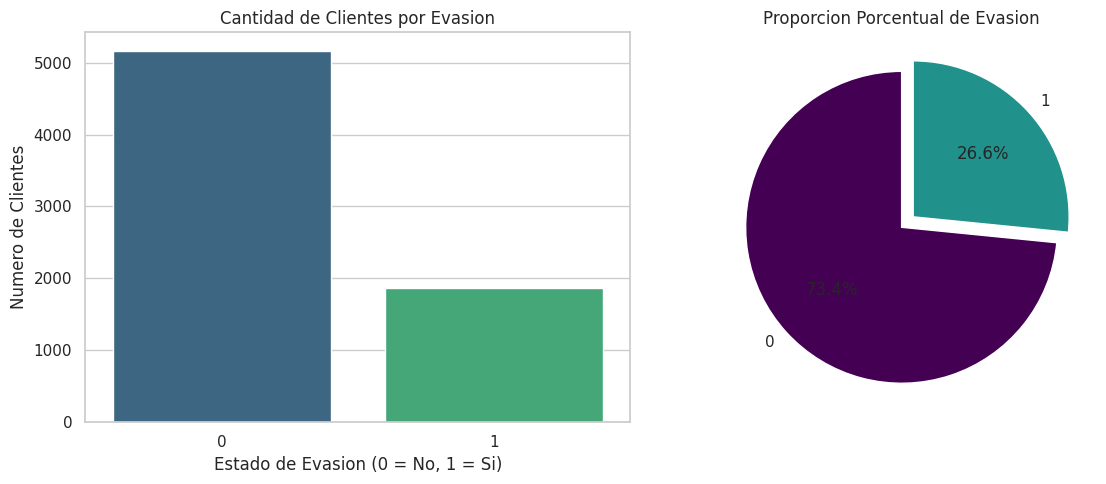

Resumen numerico de Evasion:
Evasion
0    5163
1    1869
Name: count, dtype: int64


In [31]:
# 1. Configuracion de estilo y lienzo
plt.figure(figsize=(12, 5))

# 2. Grafico de barras para ver cantidades exactas
plt.subplot(1, 2, 1)
sns.countplot(x='Evasion', data=df_final, palette='viridis')
plt.title('Cantidad de Clientes por Evasion')
plt.xlabel('Estado de Evasion (0 = No, 1 = Si)')
plt.ylabel('Numero de Clientes')

# 3. Grafico de pastel para ver proporciones porcentuales
plt.subplot(1, 2, 2)
df_final['Evasion'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#440154', '#21918c'], explode=(0, 0.1))
plt.title('Proporcion Porcentual de Evasion')
plt.ylabel('')

plt.tight_layout()
plt.show()

# 4. Tabla de frecuencias para el informe
print("Resumen numerico de Evasion:")
print(df_final['Evasion'].value_counts())

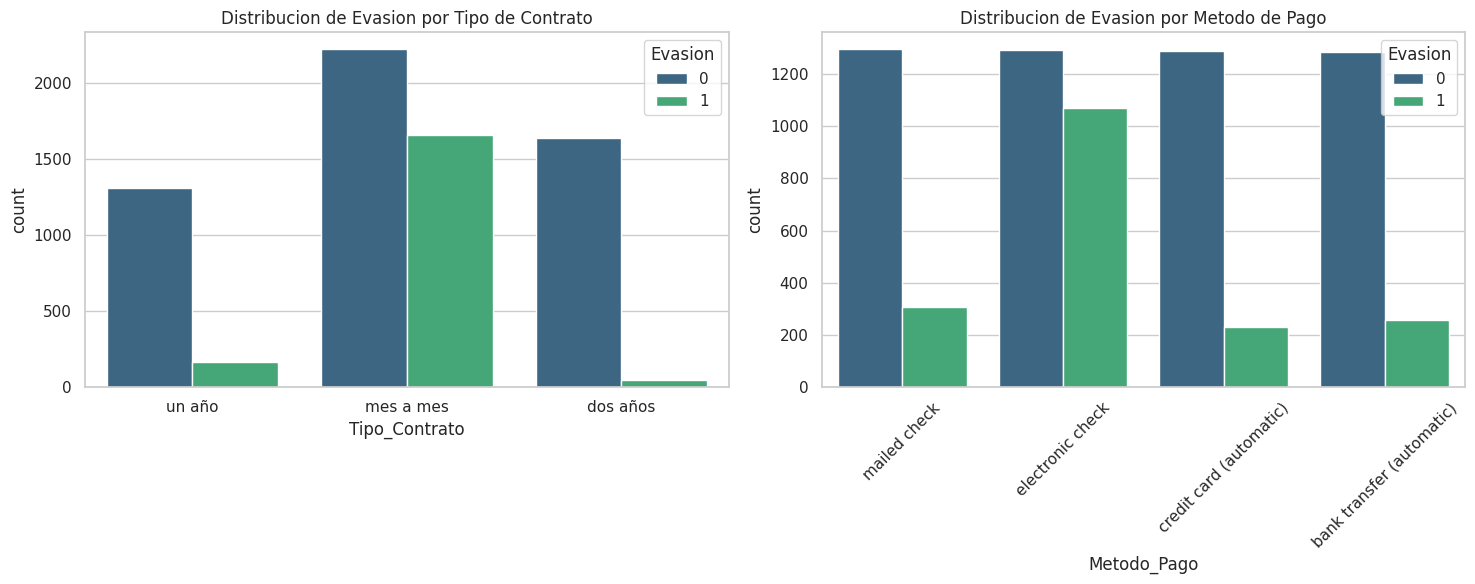

In [32]:
# Analisis de Evasion por Tipo de Contrato y Metodo de Pago
plt.figure(figsize=(15, 6))

# Grafico 1: Evasion por Tipo de Contrato
plt.subplot(1, 2, 1)
sns.countplot(x='Tipo_Contrato', hue='Evasion', data=df_final, palette='viridis')
plt.title('Distribucion de Evasion por Tipo de Contrato')

# Grafico 2: Evasion por Metodo de Pago
plt.subplot(1, 2, 2)
sns.countplot(x='Metodo_Pago', hue='Evasion', data=df_final, palette='viridis')
plt.title('Distribucion de Evasion por Metodo de Pago')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

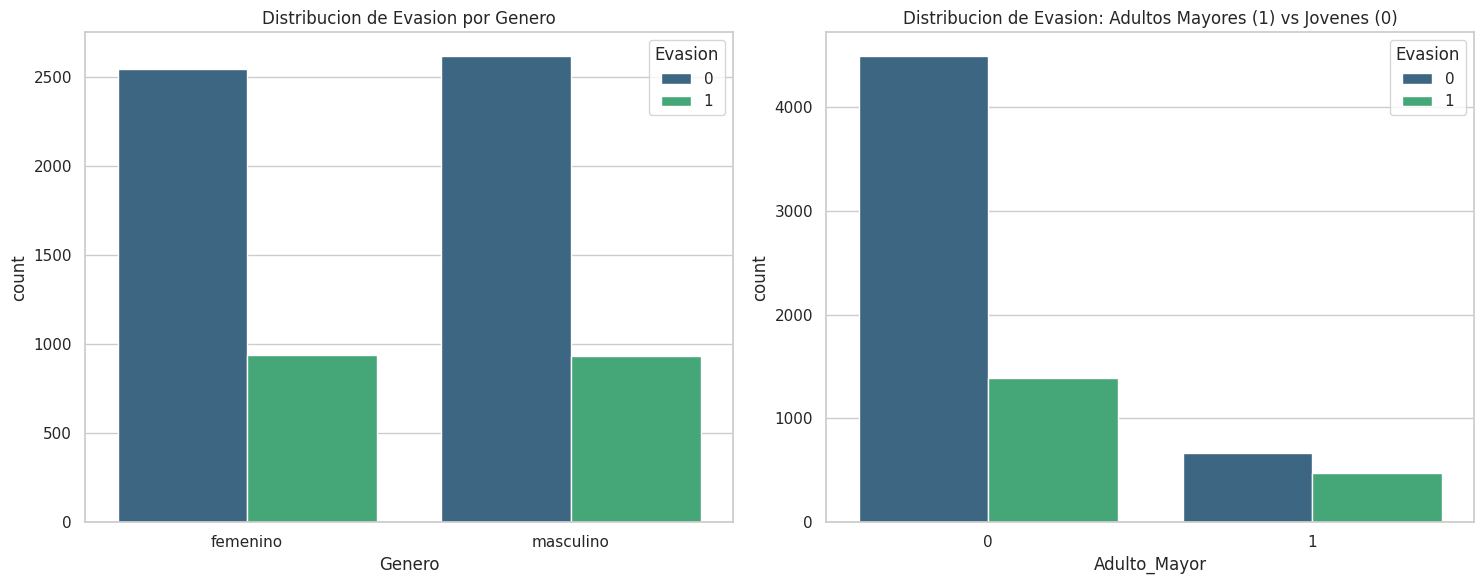

In [33]:
# Analisis de Evasion por Genero y Adulto Mayor
plt.figure(figsize=(15, 6))

# Grafico 1: Evasion por Genero
plt.subplot(1, 2, 1)
sns.countplot(x='Genero', hue='Evasion', data=df_final, palette='viridis')
plt.title('Distribucion de Evasion por Genero')

# Grafico 2: Evasion por Adulto Mayor
plt.subplot(1, 2, 2)
sns.countplot(x='Adulto_Mayor', hue='Evasion', data=df_final, palette='viridis')
plt.title('Distribucion de Evasion: Adultos Mayores (1) vs Jovenes (0)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_382/1194802852.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasion', y='Meses_Permanencia', data=df_final, ax=axes[0, 0], palette='viridis')
/tmp/ipykernel_382/1194802852.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasion', y='Cargos_Mensuales', data=df_final, ax=axes[0, 1], palette='viridis')
/tmp/ipykernel_382/1194802852.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasion', y='Cargos_Totales', data=df_final, ax=axes[1, 0], palette='viridis')
/tmp/ipykernel_382/1194802852.py:20: FutureWarni

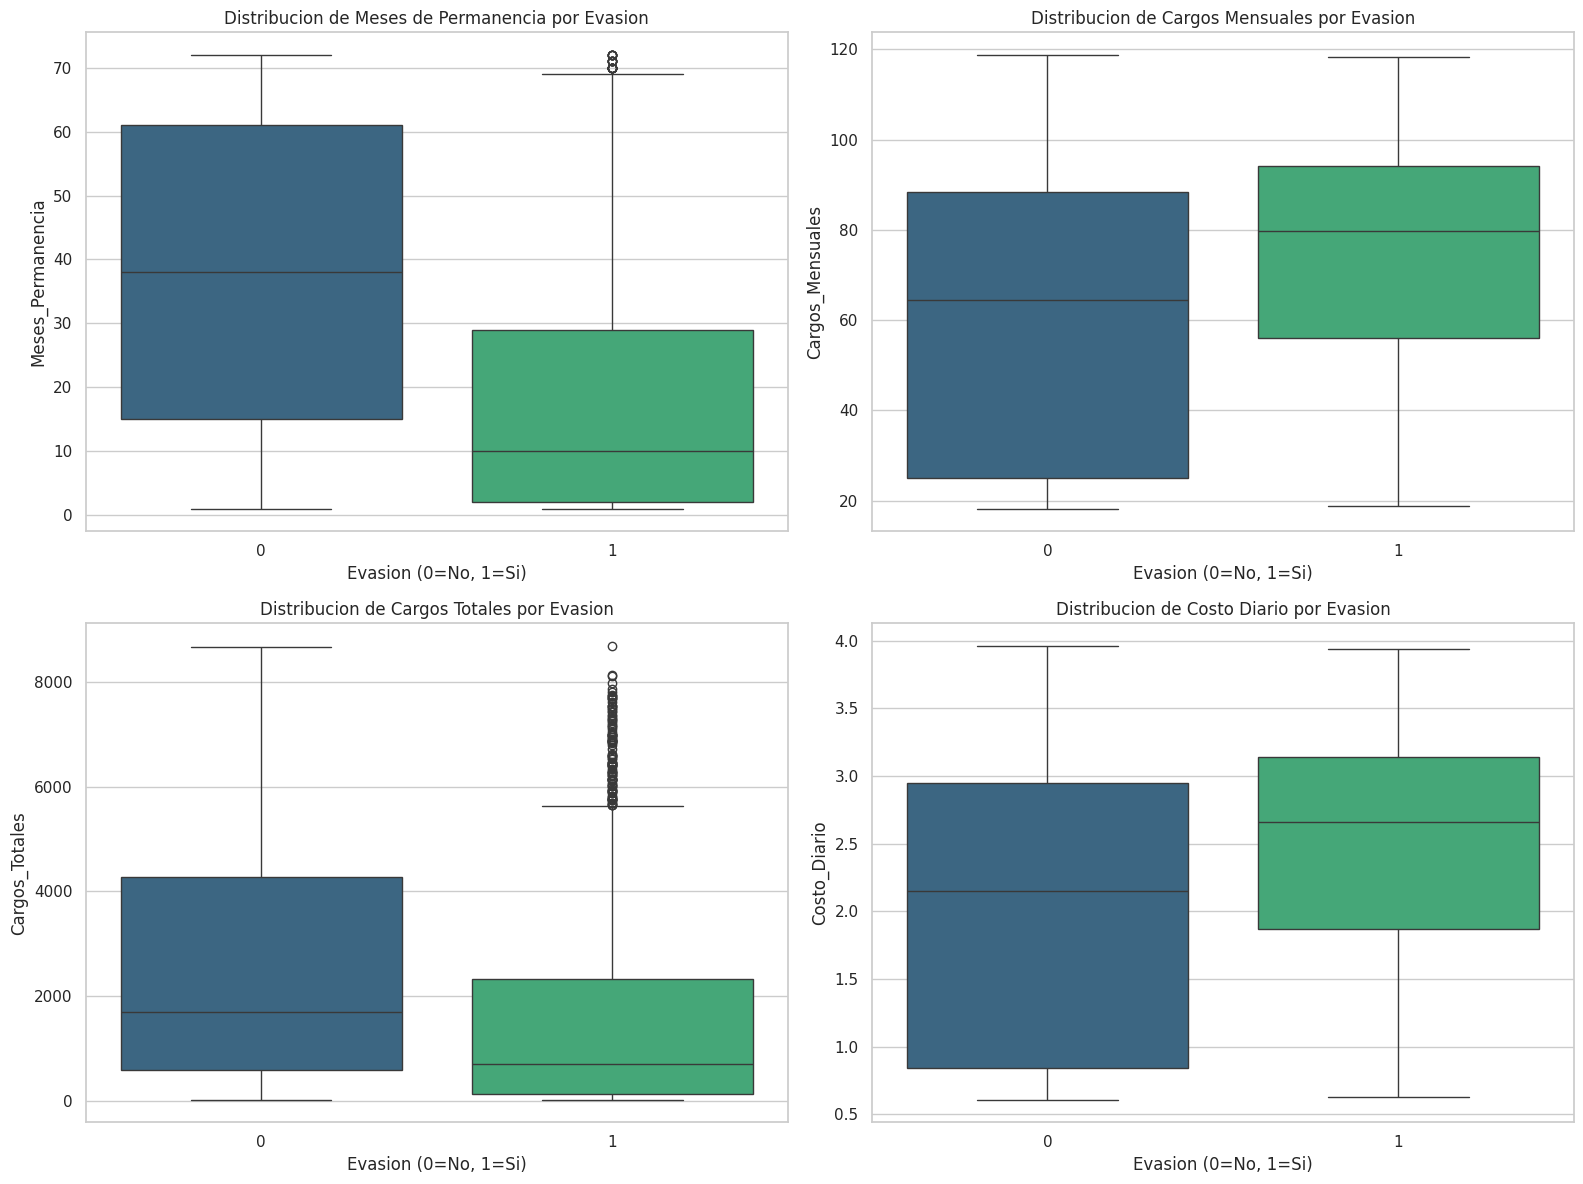

Mediana de variables numericas segun Evasion:
         Meses_Permanencia  Cargos_Mensuales  Cargos_Totales
Evasion                                                     
0                     38.0             64.45         1683.60
1                     10.0             79.65          703.55


In [34]:
# Configuracion de los graficos para variables numericas
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribucion de Meses de Permanencia por Evasion
sns.boxplot(x='Evasion', y='Meses_Permanencia', data=df_final, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Distribucion de Meses de Permanencia por Evasion')
axes[0, 0].set_xlabel('Evasion (0=No, 1=Si)')

# 2. Distribucion de Cargos Mensuales por Evasion
sns.boxplot(x='Evasion', y='Cargos_Mensuales', data=df_final, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Distribucion de Cargos Mensuales por Evasion')
axes[0, 1].set_xlabel('Evasion (0=No, 1=Si)')

# 3. Distribucion de Cargos Totales por Evasion
sns.boxplot(x='Evasion', y='Cargos_Totales', data=df_final, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Distribucion de Cargos Totales por Evasion')
axes[1, 0].set_xlabel('Evasion (0=No, 1=Si)')

# 4. Distribucion de Costo Diario por Evasion
sns.boxplot(x='Evasion', y='Costo_Diario', data=df_final, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Distribucion de Costo Diario por Evasion')
axes[1, 1].set_xlabel('Evasion (0=No, 1=Si)')

plt.tight_layout()
plt.show()

# Resumen de medianas para comparacion directa
print("Mediana de variables numericas segun Evasion:")
print(df_final.groupby('Evasion')[['Meses_Permanencia', 'Cargos_Mensuales', 'Cargos_Totales']].median())

# Informe Final: Análisis de Evasión de Clientes (Churn) - Telecom X

## 1. Introducción
El presente informe resume el análisis de datos realizado para **Telecom X** con el objetivo de identificar las causas principales de la evasión de clientes. Mediante el uso de herramientas estadísticas y visuales, se determinó que el **26.6%** de la base de usuarios ha cancelado sus servicios, lo que requiere acciones estratégicas inmediatas.

---

## 2. Limpieza y Tratamiento de Datos
Para asegurar que las conclusiones sean precisas, se aplicaron los siguientes pasos de ingeniería de datos:
* **Extracción y Normalización**: Los datos se obtuvieron vía API y se estructuraron en un DataFrame de pandas.
* **Depuración de Inconsistencias**: Se eliminaron registros con valores vacíos, resultando en un dataset limpio de **7,032 registros**.
* **Estandarización de Texto**: Se tradujeron las columnas al español y se normalizaron las categorías a minúsculas para evitar duplicidad de datos.
* **Transformación Binaria**: Las variables cualitativas (si/no) se convirtieron a valores numéricos (1/0) para permitir el análisis matemático.
* **Métricas Personalizadas**: Se creó la columna **Costo_Diario** para entender el impacto económico por cliente de forma prorrateada.

---

## 3. Análisis Exploratorio de Datos (EDA)
A través de la visualización de datos, se identificaron patrones críticos:
* **Impacto del Contrato**: Los clientes con contratos **"mes a mes"** representan el foco principal de evasión, a diferencia de los contratos a 2 años que muestran alta fidelidad.
* **Métodos de Pago**: El pago por **cheque electrónico** está asociado a una tasa de cancelación significativamente más alta que los métodos automatizados.
* **Variables Numéricas**: Se detectó que los clientes que evaden suelen tener una permanencia menor a **10 meses** y presentan cargos mensuales más altos en comparación con los clientes activos.



---

## 4. Conclusiones e Insights
* **Sensibilidad al Precio**: Existe una correlación directa entre cargos mensuales elevados y la decisión de abandonar el servicio.
* **Perfil de Riesgo**: El cliente con mayor probabilidad de fuga es aquel con contrato mensual, pago por cheque electrónico y antigüedad menor a un año.
* **Madurez del Cliente**: Una vez que el cliente supera los 30 meses de permanencia, la probabilidad de evasión disminuye drásticamente.

---

## 5. Recomendaciones Estratégicas
1. **Incentivos de Permanencia**: Ofrecer descuentos para migrar a clientes de contratos "mes a mes" hacia planes anuales o bianuales.
2. **Digitalización de Pagos**: Incentivar el uso de pagos automáticos para reducir la fricción y la deserción asociada al cheque electrónico.
3. **Monitoreo Preventivo**: Implementar alertas para clientes con cargos altos y baja antigüedad para ofrecer promociones de retención proactivas.

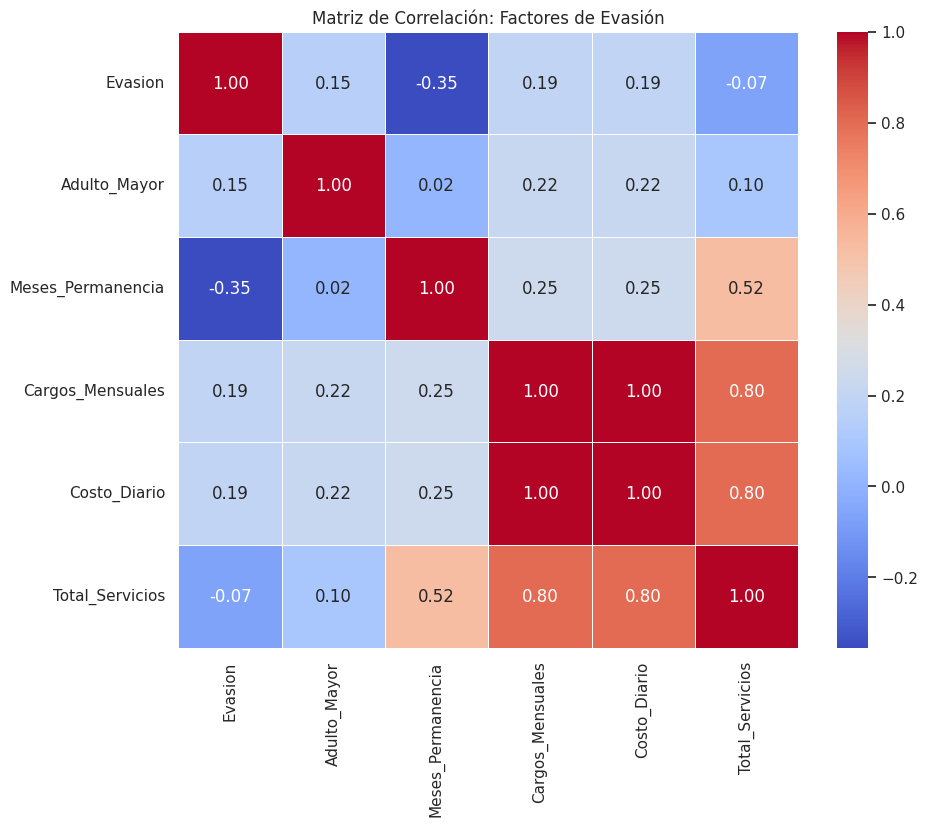

Correlación directa con la Evasión:
Evasion              1.000000
Costo_Diario         0.192914
Cargos_Mensuales     0.192858
Adulto_Mayor         0.150541
Total_Servicios     -0.067459
Meses_Permanencia   -0.354049
Name: Evasion, dtype: float64


In [35]:
# 1. Preparación de variables para correlación
# Identificamos columnas de servicios para contar el total contratado por cliente
columnas_servicios = [
    'Servicio_Telefono', 'Lineas_Multiples', 'Seguridad_Online',
    'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico',
    'Streaming_TV', 'Streaming_Peliculas'
]

# Convertimos servicios a binario (1 si tiene el servicio, 0 si no)
for col in columnas_servicios:
    if df_final[col].dtype == 'object':
        df_final[col] = df_final[col].apply(lambda x: 1 if x == 'si' or x == 'yes' else 0)

# Creamos la variable 'Total_Servicios'
df_final['Total_Servicios'] = df_final[columnas_servicios].sum(axis=1)

# 2. Cálculo de la matriz de correlación
# Seleccionamos solo las variables numéricas relevantes
columnas_analisis = [
    'Evasion', 'Adulto_Mayor', 'Meses_Permanencia',
    'Cargos_Mensuales', 'Costo_Diario', 'Total_Servicios'
]
matriz_corr = df_final[columnas_analisis].corr()

# 3. Visualización con Mapa de Calor
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Factores de Evasión')
plt.show()

# 4. Análisis específico de nuevas variables
print("Correlación directa con la Evasión:")
print(matriz_corr['Evasion'].sort_values(ascending=False))